① Feature selection

👉 刪垃圾

② Feature creation

👉 做新資訊

③ Feature importance

👉 看誰有用

特徵創造：  
  數值運算   → A/B, A-B, A*B  
  分群       → pd.cut() 把連續值變類別  
  時間特徵   → 距今天數、星期幾、月份  
 
特徵選擇：  
  feature_importances_ → 看重要性  
  設定閾值砍掉不重要的特徵  

原則：  
  不是特徵越多越好  
  好特徵 > 多特徵  
  創造後要驗證有沒有真的提升  


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False



(df['購買次數'] > 25) & (df['上次購買天數'] < 180)  
→ 結果是 True / False（布林值）  

.astype(int)  
→ True  變成 1  
→ False 變成 0  

模型只吃數字，不能吃 True/False  
所以要轉換  

pd.DataFrame(
    np.array([[1,2],[3,4]]),
    columns=['A', 'B']
)  
   A  B
0  1  2
1  3  4

df.head()          # 看前5筆
df.shape           # 幾列幾欄
df.info()          # 欄位類型
df.describe()      # 統計摘要
df['欄位名']       # 選一欄
df[['A', 'B']]     # 選多欄
df.drop('欄位', axis=1)  # 刪除欄位

1. np.random.randint(18, 65, n)  
randint = 隨機整數  
18      = 最小值  
65      = 最大值（不包含）  
n       = 產生幾個  

結果：產生 1000 個 18~64 的隨機整數  

In [23]:
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    '年齡': np.random.randint(18, 65, n),
    '收入': np.random.randint(20000, 200000, n),
    '消費金額': np.random.randint(1000, 50000, n),
    '購買次數': np.random.randint(1, 50, n),
    '上次購買天數': np.random.randint(1, 365, n), 
})

# 加入雜訊讓問題變難
df['再購買'] = (
    (df['購買次數'] > 25) & 
    (df['上次購買天數'] < 180) & 
    (np.random.random(n) > 0.3)  # 即使客戶符合條件，也只有約 70% 會被標成 1
).astype(int)

print(f"再購買比例: {df['再購買'].mean():.2%}")

再購買比例: 18.20%


df.drop('再購買', axis=1)

drop  = 刪除
'再購買' = 要刪除的欄位名稱
axis=1 = 刪除欄位方向（1=column，0=raw）

意思是：
把「再購買」這欄從 df 裡拿掉
剩下的就是特徵 X

因為「再購買」是答案 y
不能放進特徵裡
不然模型直接看答案，作弊

In [24]:
X = df.drop('再購買', axis=1)
y = df['再購買']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print(f"原始特徵準確率: {accuracy_score(y_test, model.predict(X_test)):.4f}")

原始特徵準確率: 0.9100


平均消費 = 消費金額 / 購買次數
  → 每次買多少錢
  → 比單看消費金額更有意義
  → 消費10000買10次 vs 消費10000買1次
    行為完全不同

消費收入比 = 消費金額 / 收入
  → 這個人花了收入的幾%
  → 有錢人花10000 vs 窮人花10000
    意義完全不同

年齡層 = 把連續年齡變成分群
  → 18~30歲、31~45歲、46~65歲
  → 不同年齡層購買行為不同

# pd.cut(df_new['年齡'], bins=[0,30,45,65], labels=[0,1,2])  
pd.cut = 把連續數字切成區間  

bins=[0, 30, 45, 65] → 切三段  
  0~30   → 標記為 0（年輕）  
  30~45  → 標記為 1（中年）  
  45~65  → 標記為 2（老年）  
labels 產生的是 pandas 的 Categorical（類別型）
.astype(int) → 把標籤轉成整數  

In [25]:
df_new = df.copy()

# 新特徵1：消費金額 / 購買次數 = 每次平均消費
df_new['平均消費'] = df_new['消費金額'] / df_new['購買次數']

# 新特徵2：收入中花了多少比例
df_new['消費收入比'] = df_new['消費金額'] / df_new['收入']

# 新特徵3：年齡分群
df_new['年齡層'] = pd.cut(df_new['年齡'], 
                          bins=[0, 30, 45, 65], 
                          labels=[0, 1, 2]).astype(int)

print(df_new.head())

   年齡      收入   消費金額  購買次數  上次購買天數  再購買          平均消費     消費收入比  年齡層
0  56  136748   7570    20      68    0    378.500000  0.055357    2
1  46   25287   4249     6     351    0    708.166667  0.168031    2
2  32  185459  10110    12     321    0    842.500000  0.054513    1
3  60   28512  41363     2      49    0  20681.500000  1.450723    2
4  25  152414  14605     7     175    0   2086.428571  0.095825    0


In [26]:
X_new = df_new.drop('再購買', axis=1)
y_new = df_new['再購買']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train_new)
print(f"原始特徵準確率: 0.9100")
print(f"新特徵準確率:   {accuracy_score(y_test_new, model_new.predict(X_test_new)):.4f}")

原始特徵準確率: 0.9100
新特徵準確率:   0.8850


反而下降了，這也是正常現象：
不是所有新特徵都有幫助
有時候新特徵反而引入雜訊
讓模型更難學

# X_new.columns.tolist()  
.columns     → 取得所有欄位名稱  
.tolist()    → 轉成 Python 列表  

結果：['年齡', '收入', '消費金額', ...]  

#  model_new.feature_importances_  
Random Forest 訓練完後  
自動計算每個特徵的重要程度  
數字越大 = 越重要  
所有特徵加起來 = 1.0  

# .sort_values('重要性', ascending=False)  
 依照「重要性由大到小排序」 

ascending=False 是什麼？  
排序方向   
設定	意思  
True	小 → 大  
False	大 → 小  

       特徵       重要性
4  上次購買天數  0.355953
3    購買次數  0.225925
5    平均消費  0.139049
2    消費金額  0.075329
1      收入  0.072810
6   消費收入比  0.069834
0      年齡  0.050512
7     年齡層  0.010588


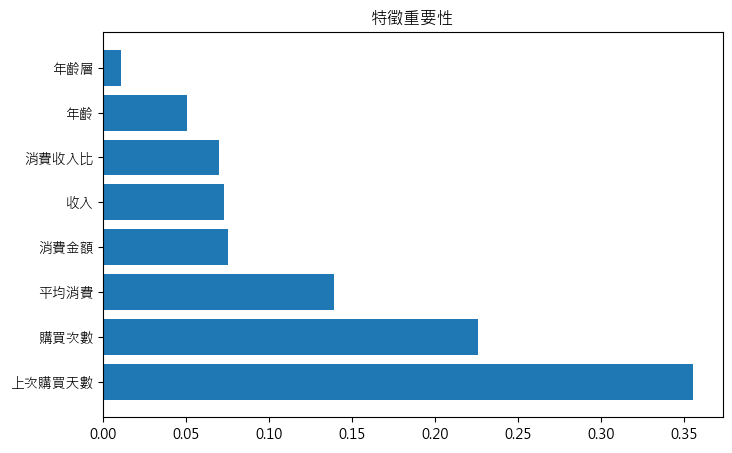

In [27]:
feature_names = X_new.columns.tolist()
importance = model_new.feature_importances_

df_imp = pd.DataFrame({
    '特徵': feature_names,
    '重要性': importance
}).sort_values('重要性', ascending=False)

print(df_imp)

plt.figure(figsize=(8, 5))
plt.barh(df_imp['特徵'], df_imp['重要性'])
plt.title('特徵重要性')
plt.show()

df_imp[df_imp['重要性'] > 0.05]['特徵'].tolist()  

df_imp[df_imp['重要性'] > 0.05]  
→ 篩選重要性大於 0.05 的列  

['特徵']  
→ 只取特徵名稱那欄  

.tolist()  
→ 轉成列表  

結果：['上次購買天數', '購買次數', ...]  

In [28]:
# 只保留重要性 > 0.05 的特徵
good_features = df_imp[df_imp['重要性'] > 0.05]['特徵'].tolist()
print(f"保留的特徵: {good_features}")

X_selected = X_new[good_features]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_new, test_size=0.2, random_state=42
)

model_sel = RandomForestClassifier(random_state=42)
model_sel.fit(X_train_sel, y_train_sel)
print(f"原始特徵準確率:   0.9100")
print(f"新特徵準確率:     0.8850")
print(f"特徵選擇後準確率: {accuracy_score(y_test_sel, model_sel.predict(X_test_sel)):.4f}")

保留的特徵: ['上次購買天數', '購買次數', '平均消費', '消費金額', '收入', '消費收入比', '年齡']
原始特徵準確率:   0.9100
新特徵準確率:     0.8850
特徵選擇後準確率: 0.8850


1. np.random.randint(18, 65, n)  
randint = 隨機整數  
18      = 最小值  
65      = 最大值（不包含）  
n       = 產生幾個  

結果：產生 1000 個 18~64 的隨機整數  

2. df_new = df.copy()  
複製一份 df 給 df_new  
為什麼不直接 df_new = df？  

df_new = df      → 兩個指向同一份資料  
                   改 df_new 也會改到 df  

df_new = df.copy() → 真正複製一份  
                     改 df_new 不影響 df  

3. pd.cut(df_new['年齡'], bins=[0,30,45,65], labels=[0,1,2])  
pd.cut = 把連續數字切成區間  

bins=[0, 30, 45, 65] → 切三段  
  0~30   → 標記為 0（年輕）  
  30~45  → 標記為 1（中年）  
  45~65  → 標記為 2（老年）  

.astype(int) → 把標籤轉成整數  

4. X_new.columns.tolist()  
.columns     → 取得所有欄位名稱  
.tolist()    → 轉成 Python 列表  

結果：['年齡', '收入', '消費金額', ...]  

5. model_new.feature_importances_  
Random Forest 訓練完後  
自動計算每個特徵的重要程度  
數字越大 = 越重要  
所有特徵加起來 = 1.0  

6. df_imp[df_imp['重要性'] > 0.05]['特徵'].tolist()  
df_imp[df_imp['重要性'] > 0.05]  
→ 篩選重要性大於 0.05 的列  

['特徵']  
→ 只取特徵名稱那欄  

.tolist()  
→ 轉成列表  

結果：['上次購買天數', '購買次數', ...]  